In [4]:
import pandas as pd

df = pd.read_csv("../data/stats_player_week_2024.csv")
df.head()

,player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,season_type,team,...,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,fantasy_points,fantasy_points_ppr
0,00-0023459,A.Rodgers,Aaron Rodgers,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,NYJ,...,0,0,NaN,0,0,0,0,0,8.58,8.58
1,00-0023853,M.Prater,Matt Prater,K,SPEC,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,ARI,...,0,0,1.0,0,0,0,0,0,0.00,0.00
2,00-0025565,N.Folk,Nick Folk,K,SPEC,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,TEN,...,0,0,1.0,0,0,0,0,0,0.00,0.00
3,00-0026190,C.Campbell,Calais Campbell,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,MIA,...,0,0,NaN,0,0,0,0,0,0.00,0.00
4,00-0026498,M.Stafford,Matthew Stafford,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,LA,...,0,0,NaN,0,0,0,0,0,14.68,14.68


In [6]:
df_2024 = df[(df["season"] == 2024) & (df["season_type"] == "REG")]

In [7]:
qb_df = df_2024[df_2024["position"] == "QB"]

In [8]:
[col for col in qb_df.columns if "pass" in col.lower()]

['passing_yards',
 'passing_tds',
 'passing_interceptions',
 'passing_air_yards',
 'passing_yards_after_catch',
 'passing_first_downs',
 'passing_epa',
 'passing_cpoe',
 'passing_2pt_conversions',
 'def_pass_defended']

In [9]:
[col for col in qb_df.columns if "attempt" in col.lower()]

['attempts']

In [12]:
qb_season = qb_df.groupby(
    ["player_id", "player_display_name", "team"]
).agg({
    "passing_yards": "sum",
    "passing_tds": "sum",
    "passing_interceptions": "sum",
    "attempts": "sum",
    "passing_epa": "sum",
}).reset_index()

In [13]:
qb_season = qb_season[qb_season["attempts"] > 0]

qb_season["YPA"] = qb_season["passing_yards"] / qb_season["attempts"]
qb_season["TD_rate"] = qb_season["passing_tds"] / qb_season["attempts"]
qb_season["INT rate"] = qb_season["passing_interceptions"] / qb_season["attempts"]
qb_season["EPA_per_Att"] = qb_season["passing_epa"] / qb_season["attempts"]

In [14]:
qb_season.sort_values("EPA_per_Att", ascending=False).head(10)

,player_id,player_display_name,team,passing_yards,passing_tds,passing_interceptions,attempts,passing_epa,YPA,TD_rate,INT rate,EPA_per_Att
19,00-0033319,Nick Mullens,MIN,38,0,0,2,4.868726,19.000000,0.000000,0.000000,2.434363
28,00-0034577,Kyle Allen,PIT,19,0,0,1,1.432553,19.000000,0.000000,0.000000,1.432553
5,00-0028118,Tyrod Taylor,NYJ,119,3,0,22,11.063086,5.409091,0.136364,0.000000,0.502868
13,00-0032268,Marcus Mariota,WAS,364,4,0,44,18.866352,8.272727,0.090909,0.000000,0.428781
73,00-0039398,Joe Milton,NE,241,1,0,29,11.790716,8.310345,0.034483,0.000000,0.406576
22,00-0033869,Mitchell Trubisky,BUF,179,2,0,26,9.716510,6.884615,0.076923,0.000000,0.373712
30,00-0034796,Lamar Jackson,BAL,4172,41,4,474,172.278612,8.801688,0.086498,0.008439,0.363457
60,00-0038400,Tanner McKee,PHI,323,4,0,45,14.677713,7.177778,0.088889,0.000000,0.326171
17,00-0033106,Jared Goff,DET,4629,37,12,539,168.554690,8.588126,0.068646,0.022263,0.312717
47,00-0036928,Kyle Trask,TB,5,0,0,1,0.297811,5.000000,0.000000,0.000000,0.297811


In [15]:
qb_season["attempts"].describe()

count     76.000000
mean     233.907895
std      206.255646
min        1.000000
25%       35.250000
50%      222.000000
75%      405.500000
max      652.000000
Name: attempts, dtype: float64

In [16]:
qb_filtered = qb_season[qb_season["attempts"] >= 200]

In [17]:
qb_filtered.sort_values("EPA_per_Att", ascending=False).head(10)

,player_id,player_display_name,team,passing_yards,passing_tds,passing_interceptions,attempts,passing_epa,YPA,TD_rate,INT rate,EPA_per_Att
30,00-0034796,Lamar Jackson,BAL,4172,41,4,474,172.278612,8.801688,0.086498,0.008439,0.363457
17,00-0033106,Jared Goff,DET,4629,37,12,539,168.554690,8.588126,0.068646,0.022263,0.312717
32,00-0034857,Josh Allen,BUF,3731,28,6,483,130.108073,7.724638,0.057971,0.012422,0.269375
41,00-0036212,Tua Tagovailoa,MIA,2867,19,7,399,85.833155,7.185464,0.047619,0.017544,0.215121
31,00-0034855,Baker Mayfield,TB,4500,41,16,570,115.388628,7.894737,0.071930,0.028070,0.202436
45,00-0036442,Joe Burrow,CIN,4918,43,9,652,115.126955,7.542945,0.065951,0.013804,0.176575
55,00-0037834,Brock Purdy,SF,3864,20,12,455,77.782674,8.492308,0.043956,0.026374,0.170951
9,00-0031280,Derek Carr,NO,2145,15,5,279,47.569375,7.688172,0.053763,0.017921,0.170500
42,00-0036264,Jordan Love,GB,3389,25,11,425,62.138519,7.974118,0.058824,0.025882,0.146208
43,00-0036355,Justin Herbert,LAC,3870,23,3,504,72.120839,7.678571,0.045635,0.005952,0.143097


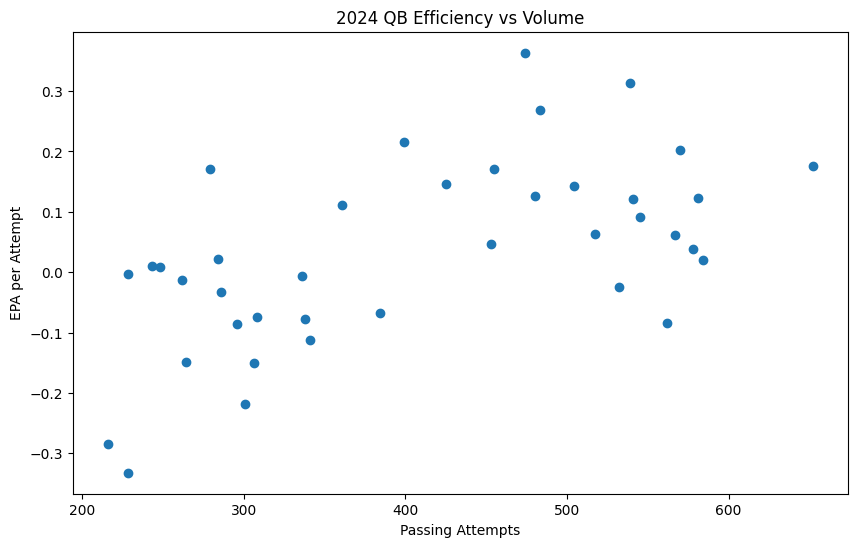

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(qb_filtered["attempts"], qb_filtered["EPA_per_Att"])

plt.xlabel("Passing Attempts")
plt.ylabel("EPA per Attempt")
plt.title("2024 QB Efficiency vs Volume")

plt.show()

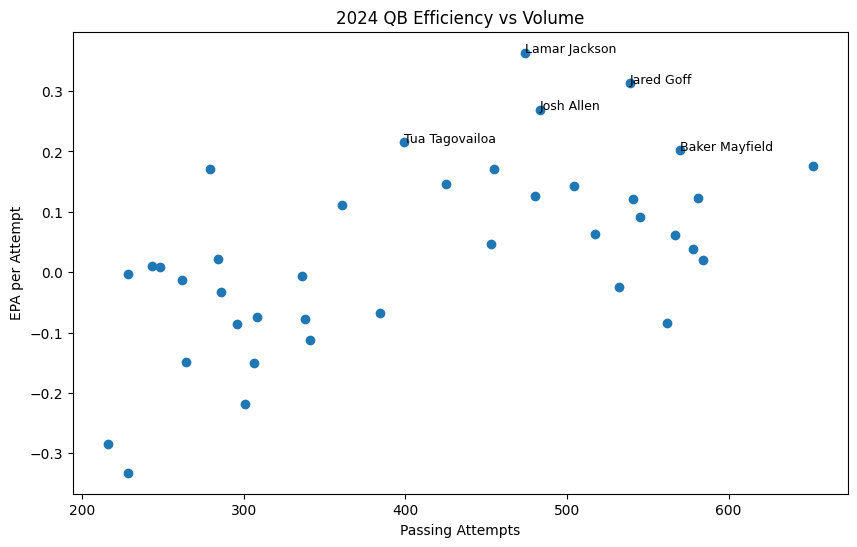

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(qb_filtered["attempts"], qb_filtered["EPA_per_Att"])

top5 = qb_filtered.sort_values("EPA_per_Att", ascending=False).head(5)

for _, row in top5.iterrows():
    plt.text(
        row["attempts"],
        row["EPA_per_Att"],
        row["player_display_name"],
        fontsize=9
    )

plt.xlabel("Passing Attempts")
plt.ylabel("EPA per Attempt")
plt.title("2024 QB Efficiency vs Volume")

plt.show()